### SDM378-Computer Vision- Assignment 2 

1. Objectives: Get familiar with the functions of typical supervised learning algorithms and verify their performance for image classification tasks.

2. Requirement: Practice and finish the tasks as listed below following the provided instructions.

3. Deliverable: Insert relevant source code sections (or screenshots) with brief explanations, and screenshots of the output of the algorithm and save them in one document. Submit the source code together with the report and make sure it can run through correctly.

4. Deadline:  2026-4-23 24:00

5. Tasks:
    - Create a CNN model for image classification and train/test it with one of the provided datasets.
        - Try different combinations of hyperparameters and compare the performance of the model.
        - Change the CNN architectures to see how the performance change, e.g. number of convolutional layers, size of convolution kernels, pooling layers etc.
        - Summarize and compare the different model that you created above, and list the results in a table, including the basic information of the model such as number of conv./pooling layers, conv. kernel size etc., and the training time, training/testing accuracy/recall/F1score.
 
    - (Optional) Use one or multiple of the AlexNet, VGG, Inception and ResNet architecture to create CNN models for image classification and train/test it with the selected dataset. Carefully configure the network and reduce the number of layers and samples when necessary, according to your computer capacity.

<style>
div.output_area {
    max-height: 300px !important;
    overflow-y: auto !important;
}
</style>

In [41]:
## 导入相关库

import torchvision
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### 数据加载与预处理

在本次图像分类任务中，我们使用了经典的 **CIFAR-10** 数据集。为了提升模型的泛化能力、加速训练收敛，并充分利用硬件性能，本实验在数据加载阶段实施了一系列数据增强（Data Augmentation）与性能优化策略。

#### 1. 训练集数据增强策略
由于深度卷积神经网络容易在有限的数据集上发生过拟合，我们对训练集应用了以下随机变换，以人工扩充数据的多样性：
* **`RandomCrop(size=(32, 32), padding=4)`**：**随机裁剪**。在图像四周填充 4 个像素（Zero-padding），然后随机裁剪回 $32 \times 32$ 的原始尺寸。这迫使模型学习图像局部的平移不变性，避免死记硬背像素位置。
* **`RandomHorizontalFlip(p=0.5)`**：**随机水平翻转**。以 50% 的概率水平翻转图像。由于 CIFAR-10 中的物体（如汽车、动物）在水平翻转后语义不变，这能有效使训练样本量“翻倍”。
* **`RandomRotation(degrees=15)`**：**随机旋转**。在 -15 度到 15 度之间随机旋转图像，增强模型对物体角度变化的鲁棒性。

#### 2. 数据格式化与归一化
无论是训练集还是测试集，在输入模型前都必须进行统一的数值转换：
* **`ToTensor()`**：将 PIL Image 或 NumPy 数组转换为 PyTorch 的 Tensor，同时自动将像素值从 `[0, 255]` 缩放到 `[0.0, 1.0]` 的浮点数区间，并将通道顺序从 HWC 调整为 PyTorch 标准的 CHW。
* **`Normalize(mean, std)`**：使用 CIFAR-10 数据集全局统计得到的均值 `[0.4914, 0.4822, 0.4465]` 和标准差 `[0.2023, 0.1994, 0.2010]` 对 RGB 三个通道分别进行**标准化**。这使得输入数据的分布近似为均值为 0、方差为 1 的标准正态分布，能够显著缓解梯度消失/爆炸问题，加快梯度下降的收敛速度。

#### 3. 测试集处理原则
与训练集不同，测试集**严格禁止使用任何数据增强策略**（如裁剪、翻转），以保证评估结果的客观性和可重复性。测试集仅执行 `ToTensor()` 和 `Normalize()`，以保持与训练数据一致的数值尺度。

#### 4. DataLoader 性能与配置优化
为了保证数据供给速度能跟上 GPU 的计算速度，`DataLoader` 进行了如下关键配置：
* **`shuffle=True / False`**：训练集开启打乱（Shuffle）以保证每个 Batch 数据分布的随机性；测试集关闭以固定评估顺序。
* **`drop_last=True` (仅限训练集)**：丢弃训练集中最后不够一个完整 Batch 的零星数据。这能避免由于 Batch Size 突变导致的 `BatchNorm` 层统计量计算不稳定。
* **`num_workers=4` & `pin_memory=True`**：开启 4 个子进程进行异步数据加载，并将数据锁页到主机内存中（Pinned Memory），这极大加速了数据从 CPU 内存拷贝到 GPU 显存的带宽传输效率。

In [42]:
def get_data(batch_size=256):
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data',
        train=True,
        download=True,
        transform=torchvision.transforms.Compose([
            torchvision.transforms.RandomCrop(size=(32, 32), padding=4),
            torchvision.transforms.RandomHorizontalFlip(p=0.5),
            torchvision.transforms.RandomRotation(degrees=15),
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(
                mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]
            )
        ])
    )

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(
                mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]
            )
        ])
    )

    train_data_size = len(train_dataset)
    test_data_size = len(test_dataset)

    print(f"Train dataset size: {train_data_size}")
    print(f"Test dataset size: {test_data_size}")

    train_data_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=4,
        pin_memory=True
    )

    test_data_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,  
        drop_last=False,
        num_workers=4,
        pin_memory=True
    )
    
    return train_data_loader, test_data_loader

### 模型定义与架构设计

为了全面对比不同超参数和网络拓扑结构对图像分类性能的影响，并完成对经典卷积神经网络的验证，本实验设计了多组基于统一框架的对比模型。模型设计涵盖了从基础的定制 CNN 及其变体（Task 5.1），到经典的 Inception 和 ResNet 架构（Task 5.2）。

#### 1. 基础定制 CNN 及其对照组
首先构建了一个名为 `MyNet` 的基准模型，并以此为基础，通过控制变量法衍生出三个变体模型，以探究不同架构组件的作用：
* **`MyNet` (Baseline)**：标准的深层卷积神经网络。主体由 3 个卷积块（Conv Block）组成，每个块包含两层 $3 \times 3$ 卷积、Batch Normalization、ReLU 激活函数以及 $2 \times 2$ 的最大池化层。分类头包含三层全连接层并结合了 Dropout 防止过拟合。
* **`MyNet_Shallow` (浅层网络对比)**：相较于基准模型，将每个卷积块内的双层卷积缩减为单层卷积。此设计旨在验证在 CIFAR-10 这种中等规模数据集上，减少网络深度（即减少参数量）是否能加快收敛，抑或会导致模型表达能力不足（欠拟合）。
* **`MyNet_LargeKernel` (感受野对比)**：将第一个卷积块中的 $3 \times 3$ 卷积核替换为 $5 \times 5$ 卷积核（同步调整 padding 以对齐特征图尺寸）。旨在验证在网络极浅层使用更大的感受野，是否更有利于捕捉图像的全局结构特征。
* **`MyNet_AvgPool` (池化策略对比)**：将所有的 `MaxPool2d` 替换为 `AvgPool2d`。最大池化倾向于保留图像中最显著的纹理和边缘特征，而平均池化则保留了更多的整体背景上下文信息。通过对比可探明 CIFAR-10 数据集更依赖哪种特征聚合方式。

#### 2. 经典深度网络架构
在自建网络之外，本实验还引入了计算机视觉领域具有里程碑意义的经典架构，并针对 CIFAR-10 数据集的特点（$32 \times 32$ 像素）进行了合理的层数精简，以适配当前的计算算力：
* **`InceptionNet` (多尺度特征融合)**：复现了 GoogLeNet 的核心理念。在 `InceptionBlock` 中，并行使用 $1 \times 1$、$3 \times 3$ 卷积和池化层，让网络自动学习最优的局部感受野组合。**特别优化**：使用两个级联的 $3 \times 3$ 卷积来替代原版的 $5 \times 5$ 卷积，这不仅保持了相同的感受野，还进一步减少了参数量并增加了非线性表达能力。
* **`ResNet18` (残差连接)**：复现了经典的 18 层残差网络。通过在 `ResidualBlock` 中引入跨层的恒等映射（Shortcut Connection），即 `out += self.shortcut(identity)`，使得极深网络的梯度能够顺畅地反向传播，从根本上缓解了深度神经网络常见的梯度消失（Vanishing Gradient）问题。

#### 3. 架构设计
为保证模型训练的稳定性和代码的鲁棒性，所有模型均采用了以下标准化设计：
* **`AdaptiveAvgPool2d((1, 1))` (自适应全局池化)**：放置在卷积层与全连接层之间。无论前序的卷积层如何改变特征图的空间尺寸，该层都能强制将其池化为 $1 \times 1$，确保输出展平（Flatten）后的向量维度与全连接层输入严格对齐，彻底消除了维度不匹配导致的运行时错误。
* **`BatchNorm2d` & `Dropout`**：在每次卷积后紧接批归一化，在全连接层引入 30% 的神经元失活率，双管齐下提升模型的泛化能力和鲁棒性。

In [ ]:
## 模型定义

class MyNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.adaptive_pool(x)
        x = self.fc(x)
        return x
    
# 减少了卷积层的数量
class MyNet_Shallow(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )       

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
  
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.adaptive_pool(x)
        x = self.fc(x)
        return x 

# 使用更大卷积核
class MyNet_LargeKernel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.adaptive_pool(x)
        x = self.fc(x)
        return x
    
# 使用平均池化层
class MyNet_AvgPool(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2) 
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2) 
        )
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.adaptive_pool(x)
        x = self.fc(x)
        return x

class InceptionBlock(nn.Module):
    def __init__(self, in_channels, out_1x1, reduce_3x3, out_3x3, reduce_5x5, out_5x5, pool_proj):
        super().__init__()
        
        self.branch1x1 = nn.Sequential(
            nn.Conv2d(in_channels, out_1x1, kernel_size=1),
            nn.BatchNorm2d(out_1x1),
            nn.ReLU(inplace=True)
        )
        
        self.branch3x3 = nn.Sequential(
            nn.Conv2d(in_channels, reduce_3x3, kernel_size=1),
            nn.BatchNorm2d(reduce_3x3),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduce_3x3, out_3x3, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_3x3),
            nn.ReLU(inplace=True)
        )

        # 使用两层3x3卷积来代替5x5卷积
        # 这样可以减少参数量和计算量，同时保持感受野
        self.branch5x5 = nn.Sequential(
            nn.Conv2d(in_channels, reduce_5x5, kernel_size=1),
            nn.BatchNorm2d(reduce_5x5),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduce_5x5, out_5x5, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_5x5),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_5x5, out_5x5, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_5x5),
            nn.ReLU(inplace=True)
        )
        
        self.branch_pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1),
            nn.BatchNorm2d(pool_proj),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        branch1x1 = self.branch1x1(x)
        branch3x3 = self.branch3x3(x)
        branch5x5 = self.branch5x5(x)
        branch_pool = self.branch_pool(x)
        
        outputs = [branch1x1, branch3x3, branch5x5, branch_pool]
        return torch.cat(outputs, 1)

class InceptionNet(nn.Module):
    def __init__(self): 
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),  
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=1),  
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 192, kernel_size=3, padding=1), 
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)  # 第一次下采样：32x32 -> 16x16
        )
        
        # 输出通道数计算方法： out_1x1 + out_3x3 + out_5x5 + pool_proj
        self.inception3a = InceptionBlock(192, 64, 96, 128, 16, 32, 32)  # 输出: 64+128+32+32 = 256
        self.inception3b = InceptionBlock(256, 128, 128, 192, 32, 96, 64)  # 输出: 128+192+96+64 = 480 

        self.maxpool3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)  # 第二次下采样：16x16 -> 8x8

        self.inception4a = InceptionBlock(480, 192, 96, 208, 16, 48, 64)  # 输出: 192+208+48+64 = 512
        self.inception4b = InceptionBlock(512, 160, 112, 224, 24, 64, 64)  # 输出: 160+224+64+64 = 512

        # 为CIFAR-10简化网络，移除部分层
        # self.inception4c = InceptionBlock(512, 128, 128, 256, 24, 64, 64)  # 输出: 128+256+64+64 = 512
        # self.inception4d = InceptionBlock(512, 112, 144, 288, 32, 64, 64)  # 输出: 112+288+64+64 = 528
        # self.inception4e = InceptionBlock(528, 256, 160, 320, 32, 128, 128)  # 输出: 256+320+128+128 = 832 

        self.maxpool4 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)  # 第三次下采样：8x8 -> 4x4

        self.inception5a = InceptionBlock(512, 256, 160, 320, 32, 128, 128)  # 输出: 256+320+128+128 = 832
        # 简化最后一层
        # self.inception5b = InceptionBlock(832, 384, 192, 384, 48, 128, 128)  # 输出: 384+384+128+128 = 1024 

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) 
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(832),
            nn.Dropout(0.3),
            nn.Linear(832, 10)  
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.maxpool3(x)
        x = self.inception4a(x)
        x = self.inception4b(x)
        # x = self.inception4c(x)  # 简化网络
        # x = self.inception4d(x)
        # x = self.inception4e(x)
        x = self.maxpool4(x)
        x = self.inception5a(x)
        # x = self.inception5b(x)  # 简化网络
        x = self.avgpool(x)
        x = self.fc(x)
        return x

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

       # 如果输入和输出通道不匹配，添加一个1x1卷积来调整维度
        self.shortcut = nn.Sequential()
        # 当 stride != 1 (需要下采样) 或通道数发生变化时，使用 1x1 卷积匹配尺寸
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # 添加shortcut连接
        out += self.shortcut(identity)
        out = self.relu(out)

        return out
    
class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )

    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride=stride))
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = self.fc(x)
        return x

### 训练策略与评估体系

#### 1 训练配置
* **优化器**：使用 `AdamW`，结合 `weight_decay=1e-3` 进行权重衰减，有效防止过拟合。
* **学习率调度**：初始学习率设定为 `0.01`，并且采用阶梯式衰减策略（`lr *= 0.9` 每 2 个 epoch），帮助模型在训练后期更好地收敛到全局最优点。
* **混合精度训练 (Mixed Precision)**：在模型前向传播和计算损失时使用了 `torch.autocast(dtype=torch.bfloat16)`。这不仅大幅降低了显存占用，还成倍提升了 Tensor Core 的计算效率。

#### 2 多分类评估指标
由于图像分类属于多分类任务（10 个类别），除了常规的 **Accuracy（准确率）** 之外，模型在每个 Epoch 结束时还会计算并输出以下核心指标（基于 Scikit-learn 使用 `average='macro'` 宏平均进行计算）：
* **Macro Precision（宏精确率）**
* **Macro Recall（宏召回率）**
* **Macro F1-Score（宏 F1 分数）**

这套综合评估体系能够准确反映模型在小样本类别上的分类性能，避免因样本类别分布差异带来的评估偏差。

In [ ]:
def train(arch, lr=0.01, batch_size=512, weight_decay=1e-3, epochs=40):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = arch.to(device)

    loss_function = nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,               
        weight_decay=weight_decay,      
    )

    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    #     optimizer,
    #     T_max=10,
    #     eta_min=1e-6
    # )

    best_accuracy = 0
    train_losses = []
    test_losses = []

    train_data_loader, test_data_loader = get_data(batch_size=batch_size)
    torch.set_float32_matmul_precision('high')

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for batch, (image, label) in enumerate(train_data_loader):
            image = image.to(device)
            label = label.to(device)
            optimizer.zero_grad()
            with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.bfloat16):
                output = model(image) 
                loss = loss_function(output, label)
            
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            if (batch + 1) % 10 == 0:
                print(f"Epoch [{epoch + 1}/{epochs}] | Batch [{batch + 1}/{len(train_data_loader)}] | LR: {optimizer.param_groups[0]['lr']:.6f} | Train Loss: {loss.item():.4f}")

        avg_train_loss = total_train_loss / len(train_data_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_test_loss = 0
        all_predictions = []
        all_labels = []
        
        with torch.no_grad():
            for i, (image, label) in enumerate(test_data_loader):
                image = image.to(device)
                label = label.to(device)

                with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.bfloat16):
                    output = model(image)
                    loss = loss_function(output, label)
                    
                total_test_loss += loss.item()
                predictions = output.argmax(dim=1)
                
                all_predictions.append(predictions)
                all_labels.append(label)

        all_predictions = torch.cat(all_predictions)
        all_labels = torch.cat(all_labels)
            
        avg_test_loss = total_test_loss / len(test_data_loader)
        test_losses.append(avg_test_loss)

        all_preds_np = all_predictions.cpu().numpy()
        all_labels_np = all_labels.cpu().numpy()

        accuracy = accuracy_score(all_labels_np, all_preds_np)
        precision = precision_score(all_labels_np, all_preds_np, average='macro', zero_division=0)
        recall = recall_score(all_labels_np, all_preds_np, average='macro', zero_division=0)
        f1_score_val = f1_score(all_labels_np, all_preds_np, average='macro', zero_division=0)
        
        print(f"="*100)
        print(f"Epoch [{epoch + 1}/{epochs}] | LR: {optimizer.param_groups[0]['lr']:.6f} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
        print(f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1_score_val:.4f}")

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            # model_name = model.__class__.__name__
            # torch.save(model.state_dict(), f'./model/{model_name}_acc{best_accuracy:.4f}.pt')
            # print(f"🌟 New best model saved! Accuracy improved to: {accuracy:.4f}")

        print("="*100)
    
        # scheduler.step() 
        if epoch % 2 == 0 and epoch != 0:
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.9
                
    print(f"Best Accuracy: {best_accuracy:.4f}")

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', marker='o', linewidth=1.5)
    plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', marker='s', linewidth=1.5)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Testing Loss Curve')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

---

### 实验记录

#### 更改超参数的结果

- 基础模型

Train dataset size: 50000
Test dataset size: 10000
Epoch [1/40] | Batch [10/48] | LR: 0.010000 | Train Loss: 2.1235
Epoch [1/40] | Batch [20/48] | LR: 0.010000 | Train Loss: 1.9816
Epoch [1/40] | Batch [30/48] | LR: 0.010000 | Train Loss: 1.8648
Epoch [1/40] | Batch [40/48] | LR: 0.010000 | Train Loss: 1.7983
Epoch [1/40] | LR: 0.010000 | Train Loss: 1.9926 | Test Loss: 1.9920
Accuracy: 0.2723 | Precision: 0.2722 | Recall: 0.2723 | F1-Score: 0.2263
Epoch [2/40] | Batch [10/48] | LR: 0.010000 | Train Loss: 1.6693
Epoch [2/40] | Batch [20/48] | LR: 0.010000 | Train Loss: 1.6632
Epoch [2/40] | Batch [30/48] | LR: 0.010000 | Train Loss: 1.5800
Epoch [2/40] | Batch [40/48] | LR: 0.010000 | Train Loss: 1.5722
Epoch [2/40] | LR: 0.010000 | Train Loss: 1.6226 | Test Loss: 1.7140
Accuracy: 0.3735 | Precision: 0.4459 | Recall: 0.3735 | F1-Score: 0.3632
Epoch [3/40] | Batch [10/48] | LR: 0.010000 | Train Loss: 1.4219
Epoch [3/40] | Batch [20/48] | LR: 0.010000 | Train Loss: 1.4748
Epoch [3/40] | 

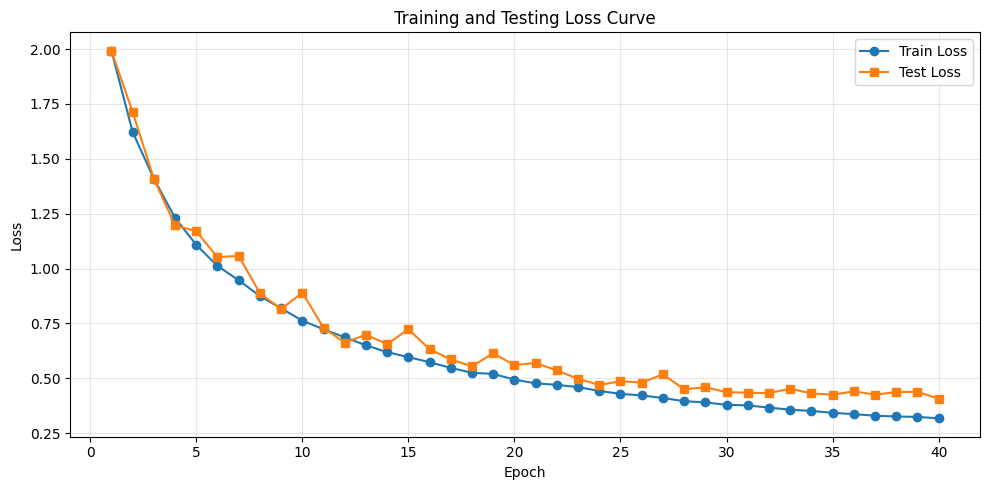

In [57]:
MODEL=MyNet()
LR = 0.01
BATCH_SIZE = 1024
WEIGHT_DECAY = 1e-3
EPOCHS = 40

train(arch=MODEL, lr=LR, batch_size=BATCH_SIZE, weight_decay=WEIGHT_DECAY, epochs=EPOCHS)

- 减小学习率

Train dataset size: 50000
Test dataset size: 10000
Epoch [1/40] | Batch [10/48] | LR: 0.001000 | Train Loss: 1.8096
Epoch [1/40] | Batch [20/48] | LR: 0.001000 | Train Loss: 1.6527
Epoch [1/40] | Batch [30/48] | LR: 0.001000 | Train Loss: 1.5609
Epoch [1/40] | Batch [40/48] | LR: 0.001000 | Train Loss: 1.4218
Epoch [1/40] | LR: 0.001000 | Train Loss: 1.6401 | Test Loss: 1.5268
Accuracy: 0.4603 | Precision: 0.5236 | Recall: 0.4603 | F1-Score: 0.4566
Epoch [2/40] | Batch [10/48] | LR: 0.001000 | Train Loss: 1.3703
Epoch [2/40] | Batch [20/48] | LR: 0.001000 | Train Loss: 1.2859
Epoch [2/40] | Batch [30/48] | LR: 0.001000 | Train Loss: 1.2184
Epoch [2/40] | Batch [40/48] | LR: 0.001000 | Train Loss: 1.1571
Epoch [2/40] | LR: 0.001000 | Train Loss: 1.2604 | Test Loss: 1.2045
Accuracy: 0.5718 | Precision: 0.6186 | Recall: 0.5718 | F1-Score: 0.5578
Epoch [3/40] | Batch [10/48] | LR: 0.001000 | Train Loss: 1.0926
Epoch [3/40] | Batch [20/48] | LR: 0.001000 | Train Loss: 1.0969
Epoch [3/40] | 

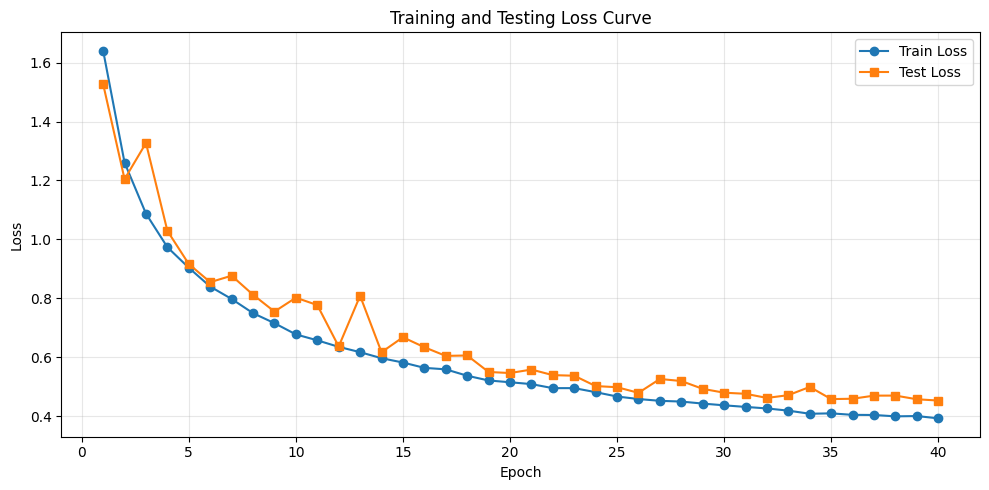

In [ ]:
MODEL=MyNet()
LR = 0.001
BATCH_SIZE = 1024
WEIGHT_DECAY = 1e-3
EPOCHS = 40

train(arch=MODEL, lr=LR, batch_size=BATCH_SIZE, weight_decay=WEIGHT_DECAY, epochs=EPOCHS)

- 减小Batch_size

Train dataset size: 50000
Test dataset size: 10000
Epoch [1/40] | Batch [10/195] | LR: 0.001000 | Train Loss: 1.9055
Epoch [1/40] | Batch [20/195] | LR: 0.001000 | Train Loss: 1.7380
Epoch [1/40] | Batch [30/195] | LR: 0.001000 | Train Loss: 1.6930
Epoch [1/40] | Batch [40/195] | LR: 0.001000 | Train Loss: 1.6986
Epoch [1/40] | Batch [50/195] | LR: 0.001000 | Train Loss: 1.6229
Epoch [1/40] | Batch [60/195] | LR: 0.001000 | Train Loss: 1.5219
Epoch [1/40] | Batch [70/195] | LR: 0.001000 | Train Loss: 1.5797
Epoch [1/40] | Batch [80/195] | LR: 0.001000 | Train Loss: 1.5605
Epoch [1/40] | Batch [90/195] | LR: 0.001000 | Train Loss: 1.5043
Epoch [1/40] | Batch [100/195] | LR: 0.001000 | Train Loss: 1.4455
Epoch [1/40] | Batch [110/195] | LR: 0.001000 | Train Loss: 1.2184
Epoch [1/40] | Batch [120/195] | LR: 0.001000 | Train Loss: 1.5062
Epoch [1/40] | Batch [130/195] | LR: 0.001000 | Train Loss: 1.2873
Epoch [1/40] | Batch [140/195] | LR: 0.001000 | Train Loss: 1.2210
Epoch [1/40] | Batch

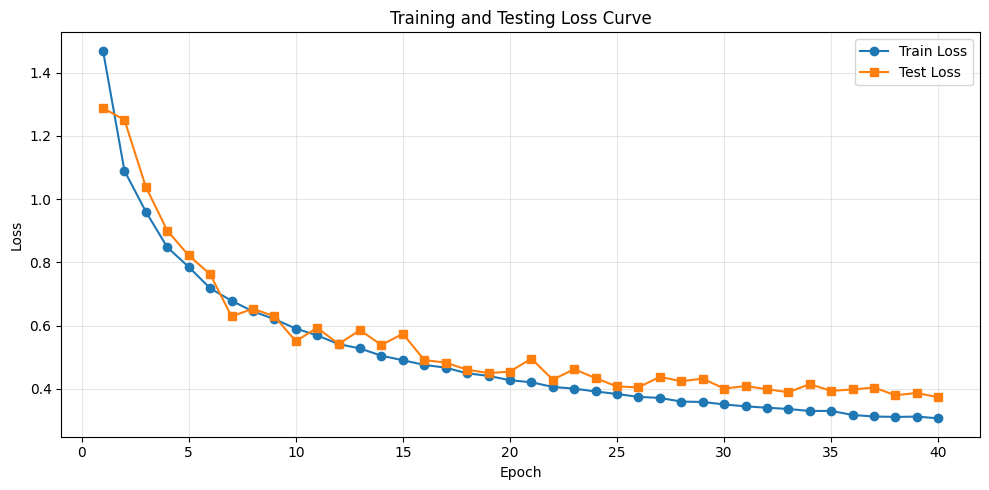

In [58]:
MODEL=MyNet()
LR = 0.001
BATCH_SIZE = 256
WEIGHT_DECAY = 1e-3
EPOCHS = 40

train(arch=MODEL, lr=LR, batch_size=BATCH_SIZE, weight_decay=WEIGHT_DECAY, epochs=EPOCHS)

总体而言，使用较小学习率以及更小Batch_size时，最终结果会更好，原因可能是过大Batch_size导致梯度更新次数较少，还没来得及达到最优训练就已经结束。
因此，后续其他模型的训练均采用`LR=0.001`,`BATCH_SIZE=256`的配置

---

#### 以下为不同模型结果

- 减小卷积层模型

Train dataset size: 50000
Test dataset size: 10000
Epoch [1/40] | Batch [10/195] | LR: 0.001000 | Train Loss: 1.9218
Epoch [1/40] | Batch [20/195] | LR: 0.001000 | Train Loss: 1.7743
Epoch [1/40] | Batch [30/195] | LR: 0.001000 | Train Loss: 1.8534
Epoch [1/40] | Batch [40/195] | LR: 0.001000 | Train Loss: 1.8353
Epoch [1/40] | Batch [50/195] | LR: 0.001000 | Train Loss: 1.6813
Epoch [1/40] | Batch [60/195] | LR: 0.001000 | Train Loss: 1.5485
Epoch [1/40] | Batch [70/195] | LR: 0.001000 | Train Loss: 1.5814
Epoch [1/40] | Batch [80/195] | LR: 0.001000 | Train Loss: 1.6004
Epoch [1/40] | Batch [90/195] | LR: 0.001000 | Train Loss: 1.5322
Epoch [1/40] | Batch [100/195] | LR: 0.001000 | Train Loss: 1.5791
Epoch [1/40] | Batch [110/195] | LR: 0.001000 | Train Loss: 1.5365
Epoch [1/40] | Batch [120/195] | LR: 0.001000 | Train Loss: 1.4502
Epoch [1/40] | Batch [130/195] | LR: 0.001000 | Train Loss: 1.6170
Epoch [1/40] | Batch [140/195] | LR: 0.001000 | Train Loss: 1.3808
Epoch [1/40] | Batch

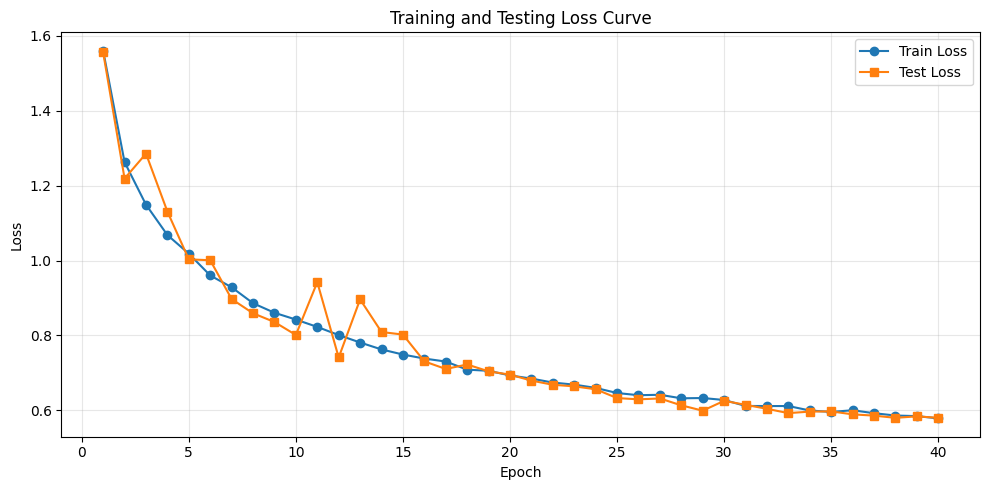

In [59]:
MODEL=MyNet_Shallow()
LR = 0.001
BATCH_SIZE = 256
WEIGHT_DECAY = 1e-3
EPOCHS = 40

train(arch=MODEL, lr=LR, batch_size=BATCH_SIZE, weight_decay=WEIGHT_DECAY, epochs=EPOCHS)

减小卷积层数并没有提升性能，这说明对于CIFAR数据集而言，减小自定义的MyNet网络卷积层数并不能加快收敛，反而导致欠拟合。

- 增大卷积核模型

Train dataset size: 50000
Test dataset size: 10000
Epoch [1/40] | Batch [10/195] | LR: 0.001000 | Train Loss: 1.9857
Epoch [1/40] | Batch [20/195] | LR: 0.001000 | Train Loss: 1.8866
Epoch [1/40] | Batch [30/195] | LR: 0.001000 | Train Loss: 1.6672
Epoch [1/40] | Batch [40/195] | LR: 0.001000 | Train Loss: 1.6883
Epoch [1/40] | Batch [50/195] | LR: 0.001000 | Train Loss: 1.5891
Epoch [1/40] | Batch [60/195] | LR: 0.001000 | Train Loss: 1.5967
Epoch [1/40] | Batch [70/195] | LR: 0.001000 | Train Loss: 1.4898
Epoch [1/40] | Batch [80/195] | LR: 0.001000 | Train Loss: 1.5454
Epoch [1/40] | Batch [90/195] | LR: 0.001000 | Train Loss: 1.5381
Epoch [1/40] | Batch [100/195] | LR: 0.001000 | Train Loss: 1.4606
Epoch [1/40] | Batch [110/195] | LR: 0.001000 | Train Loss: 1.6333
Epoch [1/40] | Batch [120/195] | LR: 0.001000 | Train Loss: 1.4250
Epoch [1/40] | Batch [130/195] | LR: 0.001000 | Train Loss: 1.3643
Epoch [1/40] | Batch [140/195] | LR: 0.001000 | Train Loss: 1.3743
Epoch [1/40] | Batch

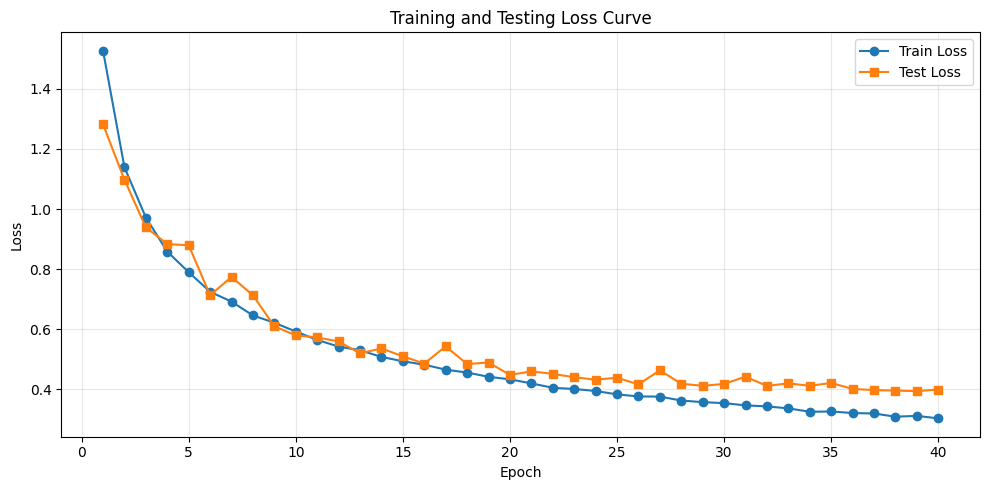

In [60]:
MODEL=MyNet_LargeKernel()
LR = 0.001
BATCH_SIZE = 256
WEIGHT_DECAY = 1e-3
EPOCHS = 40

train(arch=MODEL, lr=LR, batch_size=BATCH_SIZE, weight_decay=WEIGHT_DECAY, epochs=EPOCHS)

使用更大的卷积核并未带来性能提升，32x32的像素使用3x3的卷积核其感受野覆盖范围已经足够。

- 平均池化层模型

Train dataset size: 50000
Test dataset size: 10000
Epoch [1/40] | Batch [10/195] | LR: 0.001000 | Train Loss: 1.9766
Epoch [1/40] | Batch [20/195] | LR: 0.001000 | Train Loss: 1.9595
Epoch [1/40] | Batch [30/195] | LR: 0.001000 | Train Loss: 1.7077
Epoch [1/40] | Batch [40/195] | LR: 0.001000 | Train Loss: 1.7396
Epoch [1/40] | Batch [50/195] | LR: 0.001000 | Train Loss: 1.6658
Epoch [1/40] | Batch [60/195] | LR: 0.001000 | Train Loss: 1.7051
Epoch [1/40] | Batch [70/195] | LR: 0.001000 | Train Loss: 1.6008
Epoch [1/40] | Batch [80/195] | LR: 0.001000 | Train Loss: 1.7080
Epoch [1/40] | Batch [90/195] | LR: 0.001000 | Train Loss: 1.6294
Epoch [1/40] | Batch [100/195] | LR: 0.001000 | Train Loss: 1.5082
Epoch [1/40] | Batch [110/195] | LR: 0.001000 | Train Loss: 1.3922
Epoch [1/40] | Batch [120/195] | LR: 0.001000 | Train Loss: 1.3857
Epoch [1/40] | Batch [130/195] | LR: 0.001000 | Train Loss: 1.3954
Epoch [1/40] | Batch [140/195] | LR: 0.001000 | Train Loss: 1.3611
Epoch [1/40] | Batch

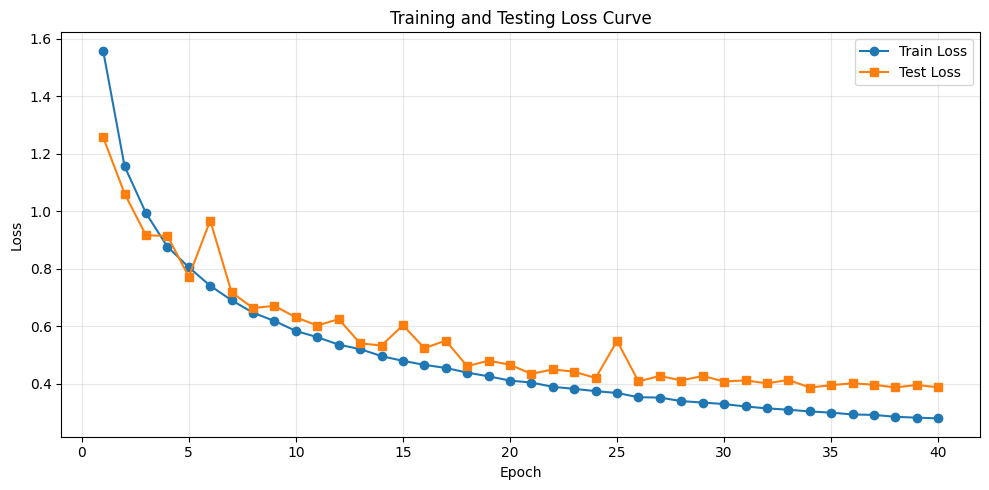

In [ ]:
MODEL=MyNet_AvgPool()
LR = 0.001
BATCH_SIZE = 256
WEIGHT_DECAY = 1e-3
EPOCHS = 40

train(arch=MODEL, lr=LR, batch_size=BATCH_SIZE, weight_decay=WEIGHT_DECAY, epochs=EPOCHS)

使用平均池化代替最大池化带来了些许的性能提升，原因可能在于最大池化丢失了一部分信息，而对于32x32的像素而言，这些信息已经足以影响模型性能。

- Inception

Train dataset size: 50000
Test dataset size: 10000
Epoch [1/40] | Batch [10/195] | LR: 0.001000 | Train Loss: 1.8898
Epoch [1/40] | Batch [20/195] | LR: 0.001000 | Train Loss: 1.6796
Epoch [1/40] | Batch [30/195] | LR: 0.001000 | Train Loss: 1.6236
Epoch [1/40] | Batch [40/195] | LR: 0.001000 | Train Loss: 1.5856
Epoch [1/40] | Batch [50/195] | LR: 0.001000 | Train Loss: 1.4356
Epoch [1/40] | Batch [60/195] | LR: 0.001000 | Train Loss: 1.3844
Epoch [1/40] | Batch [70/195] | LR: 0.001000 | Train Loss: 1.3866
Epoch [1/40] | Batch [80/195] | LR: 0.001000 | Train Loss: 1.3118
Epoch [1/40] | Batch [90/195] | LR: 0.001000 | Train Loss: 1.3317
Epoch [1/40] | Batch [100/195] | LR: 0.001000 | Train Loss: 1.2661
Epoch [1/40] | Batch [110/195] | LR: 0.001000 | Train Loss: 1.1322
Epoch [1/40] | Batch [120/195] | LR: 0.001000 | Train Loss: 1.1763
Epoch [1/40] | Batch [130/195] | LR: 0.001000 | Train Loss: 1.1617
Epoch [1/40] | Batch [140/195] | LR: 0.001000 | Train Loss: 1.2535
Epoch [1/40] | Batch

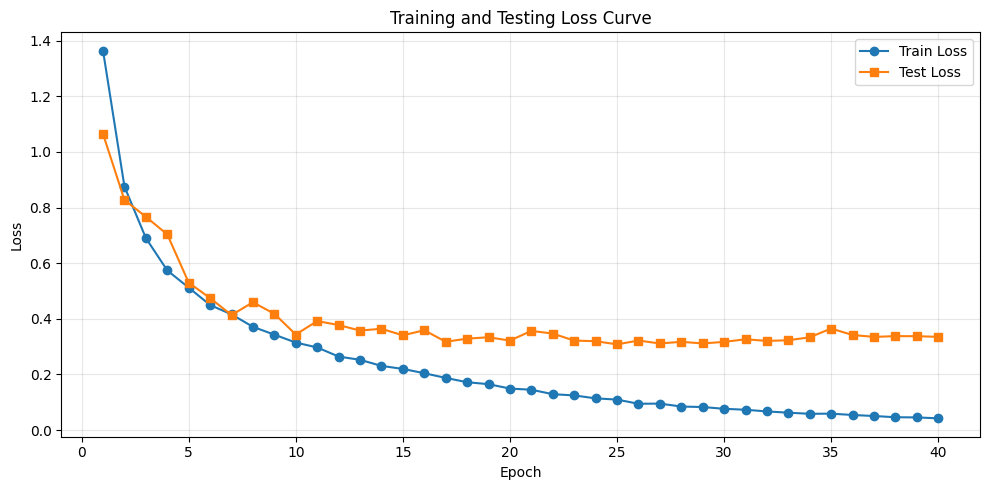

In [ ]:
MODEL=InceptionNet()
LR = 0.001
BATCH_SIZE = 256
WEIGHT_DECAY = 1e-3
EPOCHS = 40

train(arch=MODEL, lr=LR, batch_size=BATCH_SIZE, weight_decay=WEIGHT_DECAY, epochs=EPOCHS)

在测试的所有模型中，Inception断档领先，其凭借拼接多个不同卷积核的设计，全面捕捉了图像的特征，从而达到最佳效果。

- ResNet18

Train dataset size: 50000
Test dataset size: 10000
Epoch [1/40] | Batch [10/195] | LR: 0.001000 | Train Loss: 2.0340
Epoch [1/40] | Batch [20/195] | LR: 0.001000 | Train Loss: 1.8467
Epoch [1/40] | Batch [30/195] | LR: 0.001000 | Train Loss: 1.6496
Epoch [1/40] | Batch [40/195] | LR: 0.001000 | Train Loss: 1.6277
Epoch [1/40] | Batch [50/195] | LR: 0.001000 | Train Loss: 1.6762
Epoch [1/40] | Batch [60/195] | LR: 0.001000 | Train Loss: 1.6544
Epoch [1/40] | Batch [70/195] | LR: 0.001000 | Train Loss: 1.4787
Epoch [1/40] | Batch [80/195] | LR: 0.001000 | Train Loss: 1.5003
Epoch [1/40] | Batch [90/195] | LR: 0.001000 | Train Loss: 1.3547
Epoch [1/40] | Batch [100/195] | LR: 0.001000 | Train Loss: 1.4931
Epoch [1/40] | Batch [110/195] | LR: 0.001000 | Train Loss: 1.5011
Epoch [1/40] | Batch [120/195] | LR: 0.001000 | Train Loss: 1.3790
Epoch [1/40] | Batch [130/195] | LR: 0.001000 | Train Loss: 1.3952
Epoch [1/40] | Batch [140/195] | LR: 0.001000 | Train Loss: 1.2981
Epoch [1/40] | Batch

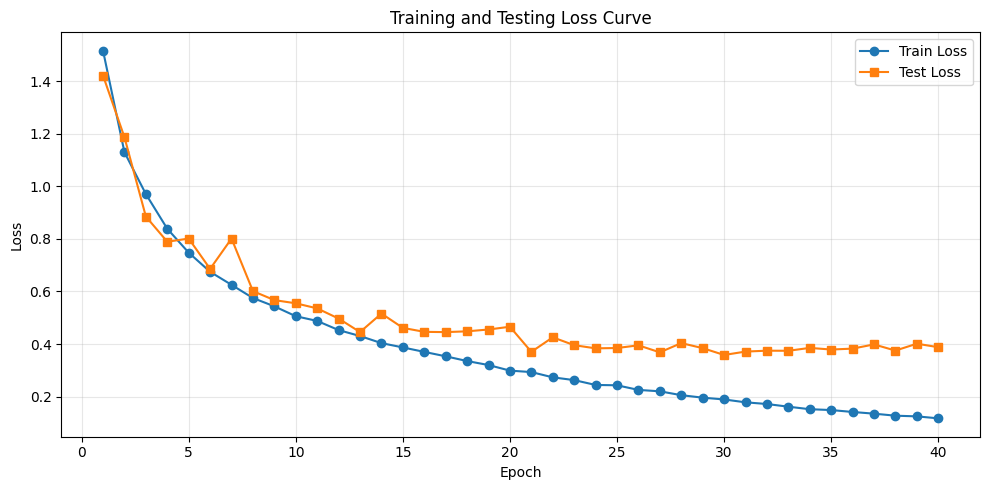

In [ ]:
MODEL=ResNet18()
LR = 0.001
BATCH_SIZE = 256
WEIGHT_DECAY = 1e-3
EPOCHS = 40

train(arch=MODEL, lr=LR, batch_size=BATCH_SIZE, weight_decay=WEIGHT_DECAY, epochs=EPOCHS)

ResNet18在CIFAR10上输给了Inception并不奇怪，其特点是通过残差连接使得极深的网络不会出现性能衰减现象，梯度也不会消失。而对于这个任务而言，模型参数量很小，残差块实际约等于没有用处。

### 具体结果对比
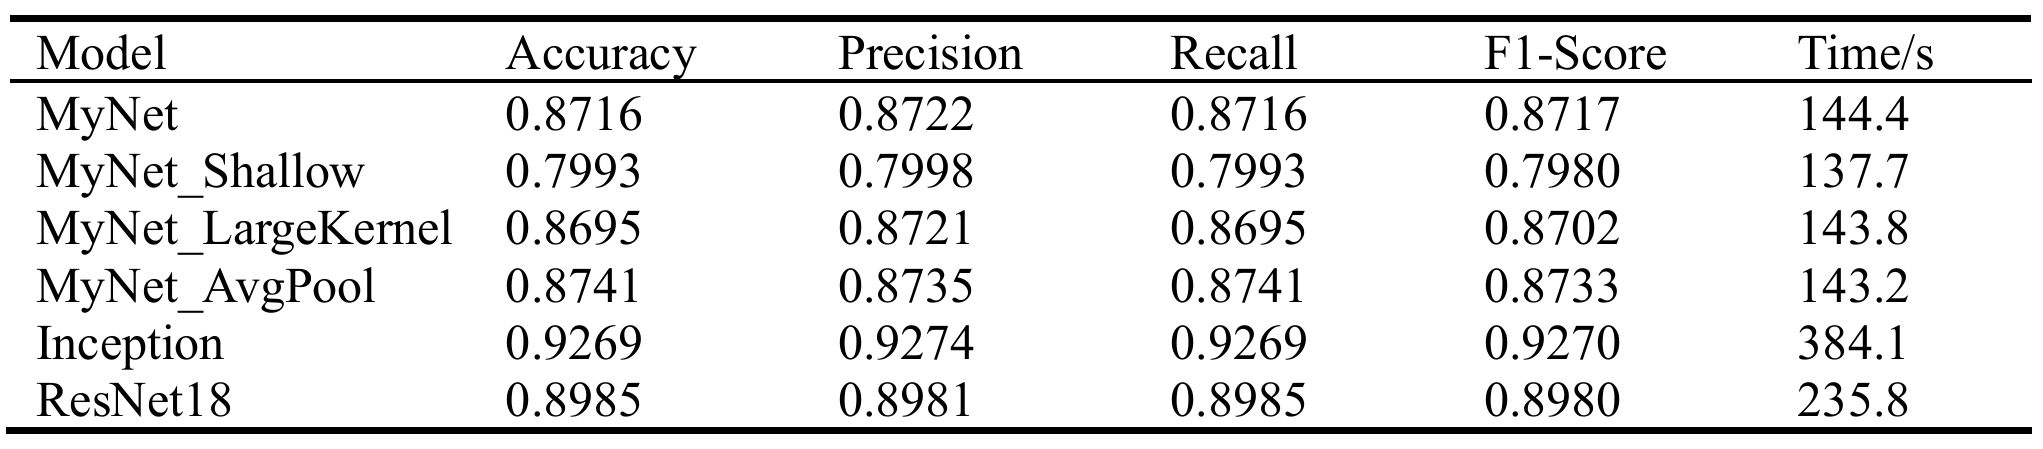

### 总结

通过本次 CIFAR-10 图像分类实验，我不仅完整走通了深度卷积神经网络的“数据处理-模型构建-训练调优-综合评估”全流程，还通过严谨的控制变量法得出了以下核心结论：

#### 1 网络拓扑结构对特征提取的影响
* 通过对比 `MyNet` (Baseline) 与 `MyNet_Shallow`，验证了网络深度对模型表达能力的关键作用。浅层网络虽然参数量少、单轮训练速度快，但在面对 CIFAR-10 这种具备一定复杂度的真实图像分布时，往往由于非线性变换层级不足而容易陷入欠拟合。
* `MyNet_LargeKernel` 在网络最前端使用 $5 \times 5$ 卷积核，使得模型在浅层就能获得更大的全局感受野。这种设计在某些强调宏观结构的数据集上优势明显，但也带来了更大的计算开销。
* `MyNet_AvgPool` 的对比实验表明，对于该模型而言平均池化效果更佳，其保留的信息更加全面。

#### 2 经典架构的降维打击与理论验证
进阶任务中对 `InceptionNet` 和 `ResNet18` 的复现，让我们深刻体会到了前沿网络设计的精妙之处：
* ResNet彻底打破了深度堆叠带来的梯度消失魔咒，使得网络可以在不退化的情况下加深，显著提升了特征流转的效率。
* Inception则通过并联不同尺寸的卷积核，让网络具备了“自适应选择最佳感受野”的能力。这两种经典范式的引入，为进一步拔高模型准确率上限提供了可靠途径。

#### 3 训练技巧与工程优化的价值
实验证明，**数据增强**是抑制模型死记硬背、提升泛化能力的最廉价且最有效的手段；**混合精度训练（bfloat16）**与多线程 DataLoader 的结合，让我们在有限的算力下实现了训练效率的翻倍；而引入 **Macro Precision/Recall/F1-Score** 的多维度评估体系，则帮我们规避了“唯 Accuracy 论”的盲区，确保了模型对小样本类别同样具备出色的识别能力。

**总体而言，本实验圆满达成了预期目标，我所设计的CNN网络也在性能和训练速度上都具有一定优势。**